# Landscapes and final plant structure
Choose landscape and snapshot files in the settings cell. `.npy` landscapes and original `.csv` landscapes are supported. Simulation snapshots are `.npy` arrays with axes `(species, row, column)`.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

# Works from the project root or the visualizations folder.
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "scripts/simulationV1.py").is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from visualizations.plot_simulation import load_landscape, plot_snapshot


In [3]:
landscape_path = "data/raw/landscape8.npy"
snapshot_path = "data/simulations/landscape8_g100_seed7_adults.npy"
reference_path = "data/CatellaData/10.csv"


## Abiotic landscape

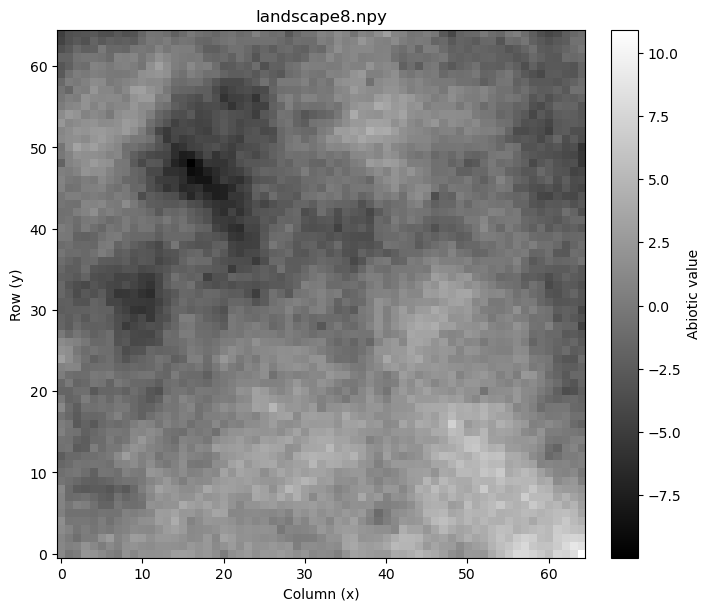

In [5]:
landscape = load_landscape(landscape_path)
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
image = ax.imshow(landscape, cmap="gray", origin="lower", interpolation="nearest")
fig.colorbar(image, ax=ax, label="Abiotic value")
ax.set(title=Path(landscape_path).name, xlabel="Column (x)", ylabel="Row (y)")
plt.show()


## Final plant community
Each species has a separate panel with a shared count scale, followed by total density and local richness. Species labels 1–4 correspond to array indices 0–3.

`adults` files show survivors **after mortality**, so baseline annual species 1 and 2 are absent. To include annuals in abundance and richness, run the simulation with `--snapshot community` and select that file above. No time history is needed.

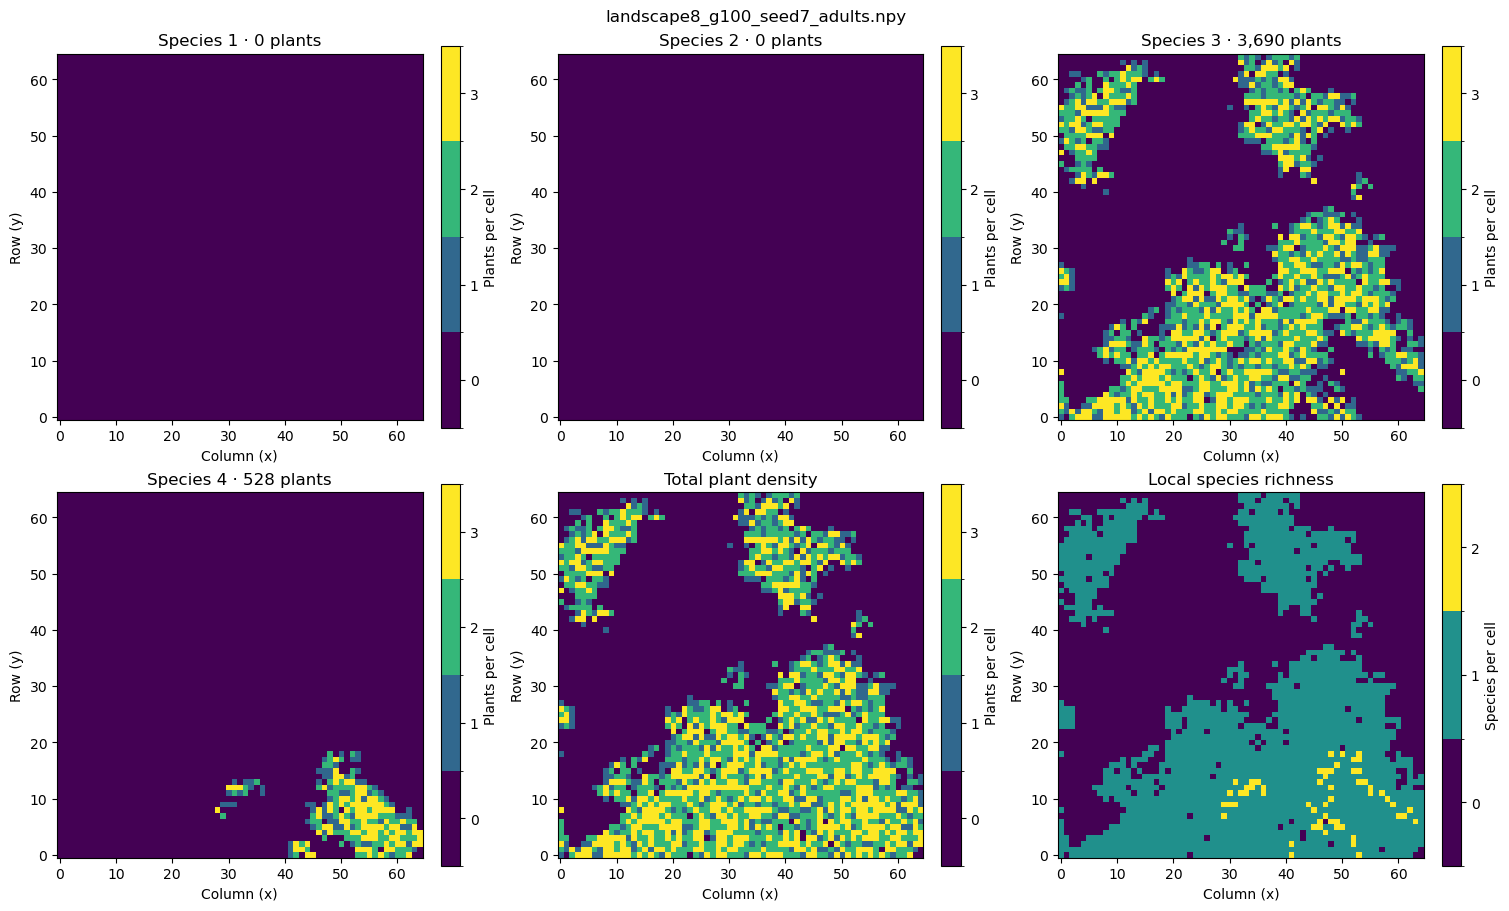

In [7]:
figure = plot_snapshot(snapshot_path)
plt.show()


## Original Catella landscape (optional CSV comparison)

#### if (PROJECT_ROOT / reference_path).exists():
    reference = load_landscape(reference_path)
    fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
    image = ax.imshow(reference, cmap="gray", origin="lower", interpolation="nearest")
    fig.colorbar(image, ax=ax, label="Abiotic value")
    ax.set(title=Path(reference_path).name, xlabel="Column (x)", ylabel="Row (y)")
    plt.show()
else:
    print(f"Optional reference file not found: {reference_path}")
